# Descripción y Análisis de los Datos

Análisis exploratorio del shapefile de incendios forestales de Uruguay. Cada registro es un **polígono del perímetro** de un incendio, identificado por evento (`EVENT`), sitio (`SITE`) y hora simulada (`HOUR`).

> **Objetivo del proyecto:** Dada la secuencia histórica de polígonos $(P_0, P_1, \dots, P_t)$, predecir el perímetro $P_{t+1}$ (predicción a un paso adelante, resolución horaria).

In [ ]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geopandas as gpd
import pyogrio
from shapely.validation import make_valid
from shapely.ops import unary_union

warnings.filterwarnings("ignore", message=".*Non closed ring detected.*")

# =========================
# CONFIGURACIÓN
# =========================
SHAPEFILE = Path("Datos/shapes_fire_UR.shp")
RANDOM_SEED = 42
N_SAMPLE_SEQUENCES = 6

# Paleta de colores (verdes)
GREEN_LIGHT  = "#a8d5a2"   # verde claro
GREEN_MAIN   = "#4caf50"   # verde medio-oscuro
GREEN_MID    = "#2e7d32"   # verde oscuro
GREEN_DARK   = "#1b5e20"   # verde muy oscuro
CMAP_GREEN   = "Greens"


# =========================
# FUNCIONES AUXILIARES
# =========================
def to_int_if_possible(s):
    s = pd.to_numeric(s, errors="coerce")
    return s.astype(int) if s.notna().all() else s


def polygonal_part(geom):
    if geom is None:
        return None
    if geom.geom_type in ("Polygon", "MultiPolygon"):
        return geom
    if geom.geom_type == "GeometryCollection":
        polys = [g for g in geom.geoms if g.geom_type in ("Polygon", "MultiPolygon")]
        return unary_union(polys) if polys else None
    return None


def safe_iou(g1, g2):
    union = g1.union(g2).area
    return g1.intersection(g2).area / union if union > 0 else np.nan


def safe_dice(g1, g2):
    denom = g1.area + g2.area
    return 2.0 * g1.intersection(g2).area / denom if denom > 0 else np.nan


## 1. Estructura General del Dataset

In [2]:
# --- Carga de datos ---
attrs = pyogrio.read_dataframe(SHAPEFILE, read_geometry=False)
gdf = gpd.read_file(SHAPEFILE, engine="pyogrio", on_invalid="fix")

for col in ["EVENT", "SITE", "HOUR", "ZONE"]:
    attrs[col] = to_int_if_possible(attrs[col])
    gdf[col] = to_int_if_possible(gdf[col])

attrs["event_site"] = attrs["EVENT"].astype(str) + "_" + attrs["SITE"].astype(str)
gdf["event_site"] = gdf["EVENT"].astype(str) + "_" + gdf["SITE"].astype(str)

# --- Resumen estructural ---
print("=" * 55)
print("  ESTRUCTURA GENERAL DEL DATASET")
print("=" * 55)
print(f"  Archivo fuente        : {SHAPEFILE}")
print(f"  CRS                   : {gdf.crs}  (UTM zona 21 S)")
print(f"  Tipo de geometría     : Polygon")
print(f"  Registros totales     : {len(attrs):,}")
print(f"  Eventos únicos        : {attrs['EVENT'].nunique()}")
print(f"  Sites únicos          : {attrs['SITE'].nunique()}")
print(f"  Secuencias EVENT×SITE : {attrs['event_site'].nunique()}")
print(f"  Rango horario         : {attrs['HOUR'].min()} – {attrs['HOUR'].max()}")
print(f"  Zonas UTM             : {sorted(attrs['ZONE'].dropna().unique().tolist())}")
print(f"  Hemisferio            : {attrs['HEMI'].unique().tolist()}")
print()
print("Primeros registros:")
display(attrs.head(8))

  ESTRUCTURA GENERAL DEL DATASET
  Archivo fuente        : Datos/shapes_fire_UR.shp
  CRS                   : EPSG:32721  (UTM zona 21 S)
  Tipo de geometría     : Polygon
  Registros totales     : 1,815
  Eventos únicos        : 98
  Sites únicos          : 13
  Secuencias EVENT×SITE : 600
  Rango horario         : 0 – 9
  Zonas UTM             : [21, 22]
  Hemisferio            : ['South']

Primeros registros:


,EVENT,SITE,HOUR,ZONE,HEMI,POL_ID,event_site
0,0,0,0,21,South,0,0_0
1,0,0,1,21,South,1,0_0
2,0,1,0,21,South,2,0_1
3,0,1,1,21,South,3,0_1
4,0,2,0,21,South,4,0_2
5,0,2,1,21,South,5,0_2
6,0,2,2,21,South,6,0_2
7,0,2,3,21,South,7,0_2


## 2. Calidad Geométrica y Limpieza

Verificación de geometrías nulas e inválidas, seguida de la corrección con `make_valid` y extracción de componentes poligonales.

In [3]:
# --- Evaluación de calidad ---
geom_nonnull = gdf.geometry.notna()
valid_nonnull = gdf.loc[geom_nonnull, "geometry"].is_valid

n_total = len(gdf)
n_null = int((~geom_nonnull).sum())
n_valid = int(valid_nonnull.sum())
n_invalid = int((~valid_nonnull).sum())

print("=" * 55)
print("  CALIDAD GEOMÉTRICA")
print("=" * 55)
print(f"  Registros totales               : {n_total:,}")
print(f"  Geometrías nulas                : {n_null}  ({100*n_null/n_total:.1f}%)")
print(f"  Geometrías válidas (no nulas)   : {n_valid:,}")
print(f"  Geometrías inválidas (no nulas) : {n_invalid}")
print(f"  Distribución por zona UTM       : {dict(attrs['ZONE'].value_counts().sort_index())}")
print()

# --- Limpieza ---
clean = gdf[gdf.geometry.notna()].copy()
clean.loc[~clean.geometry.is_valid, "geometry"] = (
    clean.loc[~clean.geometry.is_valid, "geometry"].apply(make_valid)
)
clean["geometry"] = clean["geometry"].apply(polygonal_part)
clean = clean[clean.geometry.notna()].copy()

clean["area_m2"] = clean.geometry.area
clean["area_ha"] = clean["area_m2"] / 10_000
clean["perimeter_m"] = clean.geometry.length
clean["perimeter_km"] = clean["perimeter_m"] / 1_000
clean["centroid_x"] = clean.geometry.centroid.x
clean["centroid_y"] = clean.geometry.centroid.y
clean["event_site"] = clean["EVENT"].astype(str) + "_" + clean["SITE"].astype(str)

n_clean = len(clean)
print(f"  Registros tras limpieza : {n_clean:,}  (eliminados: {n_total - n_clean})")
print(f"  → Pérdida de datos      : {100*(n_total - n_clean)/n_total:.1f}%")

  CALIDAD GEOMÉTRICA
  Registros totales               : 1,815
  Geometrías nulas                : 44  (2.4%)
  Geometrías válidas (no nulas)   : 1,761
  Geometrías inválidas (no nulas) : 10
  Distribución por zona UTM       : {21: np.int64(1774), 22: np.int64(41)}

  Registros tras limpieza : 1,771  (eliminados: 44)
  → Pérdida de datos      : 2.4%


## 3. Secuencias Temporales

Cada combinación `EVENT × SITE` define una **secuencia temporal** que describe la evolución horaria de un incendio. Para la tarea de predicción $t \to t{+}1$ se requieren secuencias con **al menos 2 pasos** temporales.

  SECUENCIAS TEMPORALES (datos limpios)
  Secuencias totales              : 600
  Secuencias utilizables (≥2 h)   : 565
  Secuencias no utilizables (1 h) : 35
  Transiciones t→t+1 disponibles  : 1,171

  Distribución de longitud de secuencias:
     1 pasos :  35  ████
     2 pasos : 320  ████████████████████████████████████████
     3 pasos : 106  █████████████
     4 pasos :  50  ██████
     5 pasos :  35  ████
     6 pasos :  16  ██
     7 pasos :  13  █
     8 pasos :  14  █
     9 pasos :   6  █
    10 pasos :   5  █



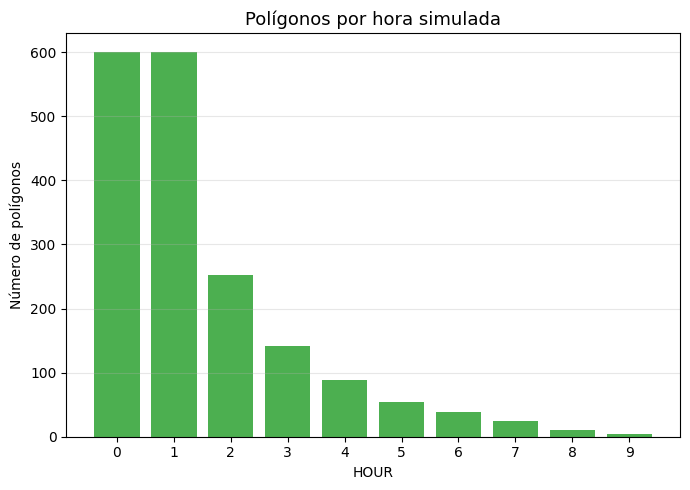

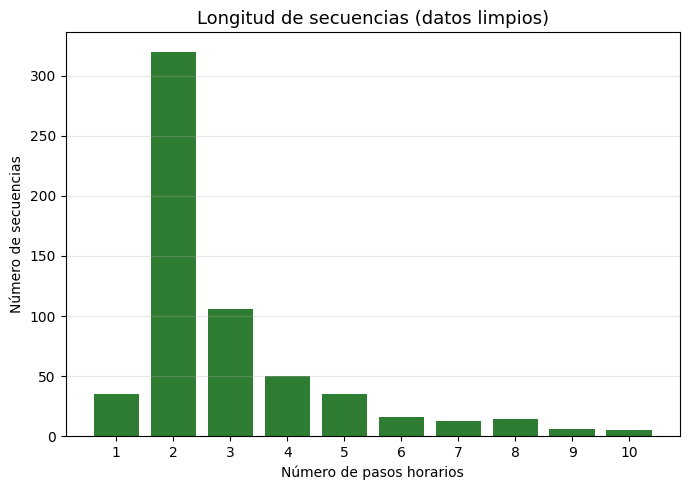

In [4]:
# --- Resumen de secuencias (datos limpios) ---
clean_seq = (
    clean.groupby(["EVENT", "SITE"], as_index=False)
    .agg(
        n_steps=("HOUR", "nunique"),
        min_hour=("HOUR", "min"),
        max_hour=("HOUR", "max"),
        n_polygons=("POL_ID", "count"),
    )
)
clean_seq["n_transitions"] = clean_seq["n_steps"] - 1
clean_seq["usable"] = clean_seq["n_steps"] >= 2

n_usable = int(clean_seq["usable"].sum())
n_transitions = int(clean_seq["n_transitions"].sum())
seq_len_dist = clean_seq["n_steps"].value_counts().sort_index()

print("=" * 55)
print("  SECUENCIAS TEMPORALES (datos limpios)")
print("=" * 55)
print(f"  Secuencias totales              : {len(clean_seq)}")
print(f"  Secuencias utilizables (≥2 h)   : {n_usable}")
print(f"  Secuencias no utilizables (1 h) : {len(clean_seq) - n_usable}")
print(f"  Transiciones t→t+1 disponibles  : {n_transitions:,}")
print()
print("  Distribución de longitud de secuencias:")
for steps, count in seq_len_dist.items():
    bar = "█" * max(1, int(count / 8))
    print(f"    {steps:>2} pasos : {count:>3}  {bar}")
print()

hour_counts = attrs["HOUR"].value_counts().sort_index()

# ----------------------------------------------------------------
# Figura 1 – Polígonos por hora simulada
# ----------------------------------------------------------------
fig_hora, ax_hora = plt.subplots(figsize=(7, 5))
ax_hora.bar(hour_counts.index.astype(str), hour_counts.values, color=GREEN_MAIN)
ax_hora.set_title("Polígonos por hora simulada", fontsize=13)
ax_hora.set_xlabel("HOUR")
ax_hora.set_ylabel("Número de polígonos")
ax_hora.grid(axis="y", alpha=0.3)
fig_hora.tight_layout()
plt.savefig("figuras_informe/fig_poligonos_por_hora.png", dpi=150, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------
# Figura 2 – Longitud de secuencias
# ----------------------------------------------------------------
fig_seq, ax_seq = plt.subplots(figsize=(7, 5))
ax_seq.bar(seq_len_dist.index.astype(str), seq_len_dist.values, color=GREEN_MID)
ax_seq.set_title("Longitud de secuencias (datos limpios)", fontsize=13)
ax_seq.set_xlabel("Número de pasos horarios")
ax_seq.set_ylabel("Número de secuencias")
ax_seq.grid(axis="y", alpha=0.3)
fig_seq.tight_layout()
plt.savefig("figuras_informe/fig_longitud_secuencias.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Distribución Geométrica y Espacial

Estadísticas de área y perímetro de los polígonos limpios, evolución del tamaño por hora simulada, y cobertura geográfica sobre Uruguay.

  ESTADÍSTICAS DE GEOMETRÍA (polígonos limpios)

  Área (ha):
    Media   : 60.15
    Mediana : 4.23
    Std     : 213.20
    Min–Max : 0.00 – 5332.71
    P25–P75 : 0.05 – 35.34
    P95     : 294.26

  Perímetro (km):
    Media   : 2.409
    Mediana : 0.771
    Std     : 4.946
    Min–Max : 0.014 – 85.454
    P25–P75 : 0.110 – 2.599
    P95     : 10.069



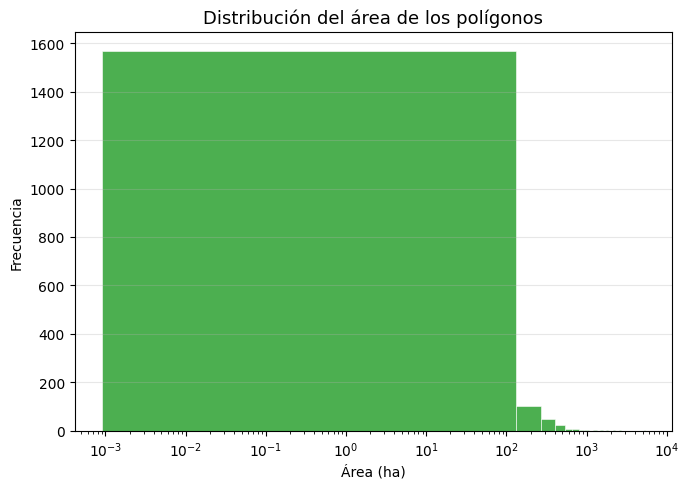

/var/folders/lp/c74rnk7n6rg_njd47w0lgj200000gn/T/ipykernel_99377/3779078879.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


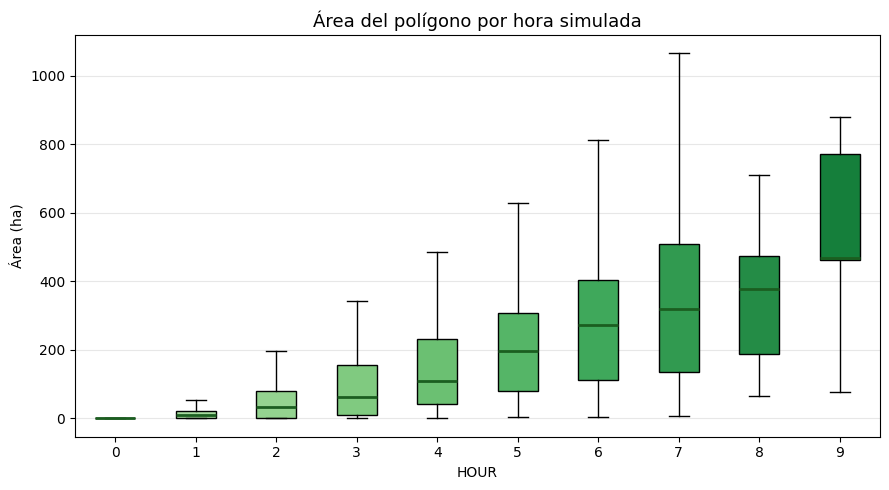

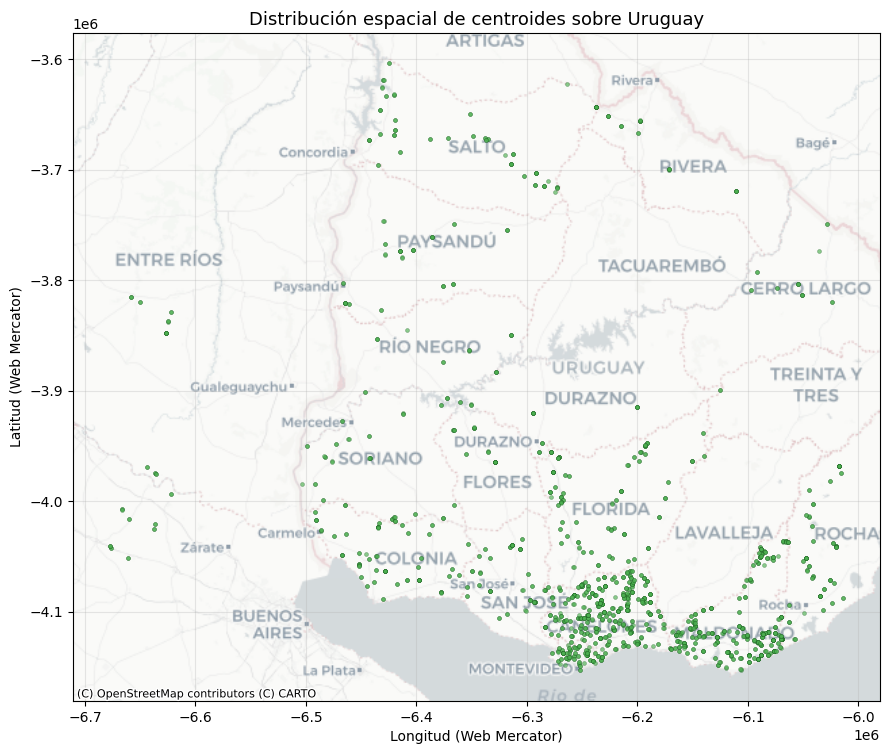

In [5]:
import contextily as ctx
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Estadísticas de geometría ---
print("=" * 55)
print("  ESTADÍSTICAS DE GEOMETRÍA (polígonos limpios)")
print("=" * 55)
for label, col, fmt in [
    ("Área (ha)", "area_ha", ".2f"),
    ("Perímetro (km)", "perimeter_km", ".3f"),
]:
    s = clean[col]
    print(f"\n  {label}:")
    print(f"    Media   : {s.mean():{fmt}}")
    print(f"    Mediana : {s.median():{fmt}}")
    print(f"    Std     : {s.std():{fmt}}")
    print(f"    Min–Max : {s.min():{fmt}} – {s.max():{fmt}}")
    print(f"    P25–P75 : {s.quantile(.25):{fmt}} – {s.quantile(.75):{fmt}}")
    print(f"    P95     : {s.quantile(.95):{fmt}}")
print()

# ----------------------------------------------------------------
# Figura 1 – Histograma de área (escala log)
# ----------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.hist(clean["area_ha"].replace(0, np.nan).dropna(), bins=40, color=GREEN_MAIN, edgecolor="white", linewidth=0.4)
ax1.set_xscale("log")
ax1.set_title("Distribución del área de los polígonos", fontsize=13)
ax1.set_xlabel("Área (ha)")
ax1.set_ylabel("Frecuencia")
ax1.grid(axis="y", alpha=0.3)
fig1.tight_layout()
plt.savefig("figuras_informe/fig_area_histograma.png", dpi=150, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------
# Figura 2 – Boxplot de área por hora simulada
# ----------------------------------------------------------------
hours_sorted = sorted(clean["HOUR"].dropna().unique().tolist())
data_by_hour = [clean.loc[clean["HOUR"] == h, "area_ha"].values for h in hours_sorted]

fig2, ax2 = plt.subplots(figsize=(9, 5))
bp = ax2.boxplot(
    data_by_hour,
    labels=[str(h) for h in hours_sorted],
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color=GREEN_DARK, linewidth=2),
)
# Colorear cajas con gradiente de verdes
cmap = plt.get_cmap(CMAP_GREEN)
n_boxes = len(bp["boxes"])
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(cmap(0.3 + 0.5 * i / max(n_boxes - 1, 1)))
ax2.set_title("Área del polígono por hora simulada", fontsize=13)
ax2.set_xlabel("HOUR")
ax2.set_ylabel("Área (ha)")
ax2.grid(axis="y", alpha=0.3)
fig2.tight_layout()
plt.savefig("figuras_informe/fig_area_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------
# Figura 3 – Distribución espacial de centroides sobre Uruguay
# ----------------------------------------------------------------
# Reproyectar a Web Mercator para compatibilidad con tiles de contextily
centroids_gdf = gpd.GeoDataFrame(
    clean[["centroid_x", "centroid_y", "area_ha"]].copy(),
    geometry=gpd.points_from_xy(clean["centroid_x"], clean["centroid_y"]),
    crs=clean.crs,
).to_crs(epsg=3857)

fig3, ax3 = plt.subplots(figsize=(9, 9))

centroids_gdf.plot(
    ax=ax3,
    markersize=8,
    alpha=0.65,
    color=GREEN_MAIN,
    edgecolors=GREEN_DARK,
    linewidth=0.3,
    zorder=2,
)

# Añadir mapa base de Uruguay
ctx.add_basemap(ax3, source=ctx.providers.CartoDB.Positron, zoom=7)

ax3.set_title("Distribución espacial de centroides sobre Uruguay", fontsize=13)
ax3.set_xlabel("Longitud (Web Mercator)")
ax3.set_ylabel("Latitud (Web Mercator)")
ax3.grid(alpha=0.3, zorder=1)
fig3.tight_layout()
plt.savefig("figuras_informe/fig_centroides_uruguay.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Métricas de Transición $t \to t{+}1$

Propiedades de las transiciones entre polígonos consecutivos en cada secuencia. Estas métricas caracterizan la **dinámica que el modelo deberá aprender a predecir**: crecimiento de área, solapamiento (IoU / Dice), contención y desplazamiento del centroide.

  MÉTRICAS DE TRANSICIÓN t → t+1
  Transiciones analizadas      : 1,171
  t contenido en t+1           : 98.2%

  IoU:
    Media / Mediana : 0.280 / 0.246
    P25 – P75       : 0.004 – 0.498
    P95             : 0.775

  Dice:
    Media / Mediana : 0.365 / 0.395
    P25 – P75       : 0.007 – 0.665
    P95             : 0.873

  Crecimiento (ha):
    Media / Mediana : 44.34 / 19.59
    P25 – P75       : 2.61 – 50.71
    P95             : 148.24

  Desplazamiento centroide (m):
    Media / Mediana : 75.0 / 46.2
    P25 – P75       : 12.0 – 91.6
    P95             : 225.3



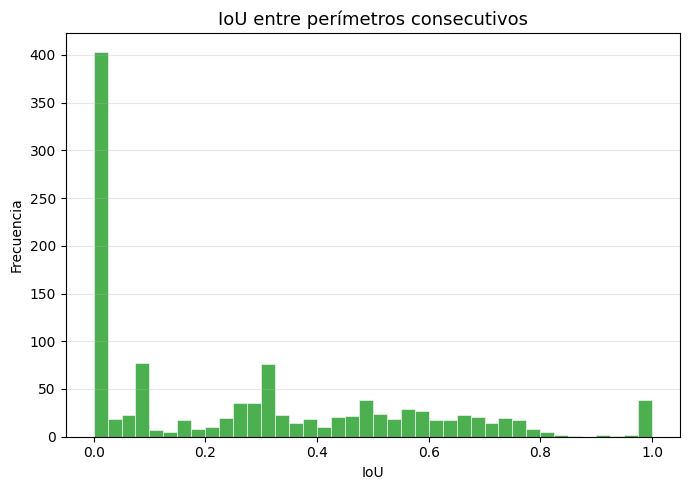

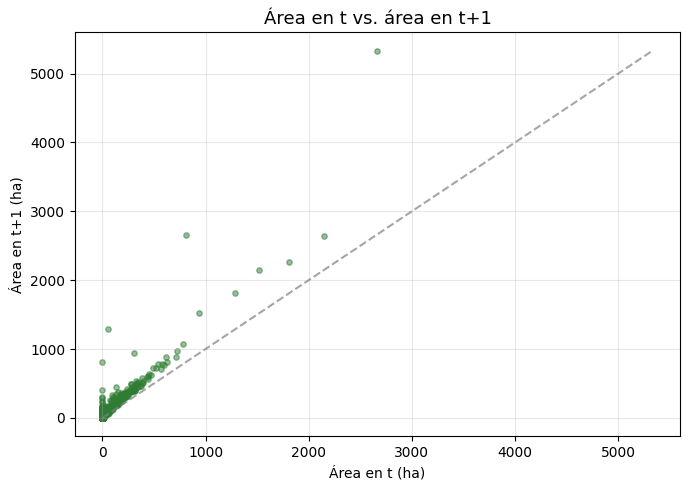

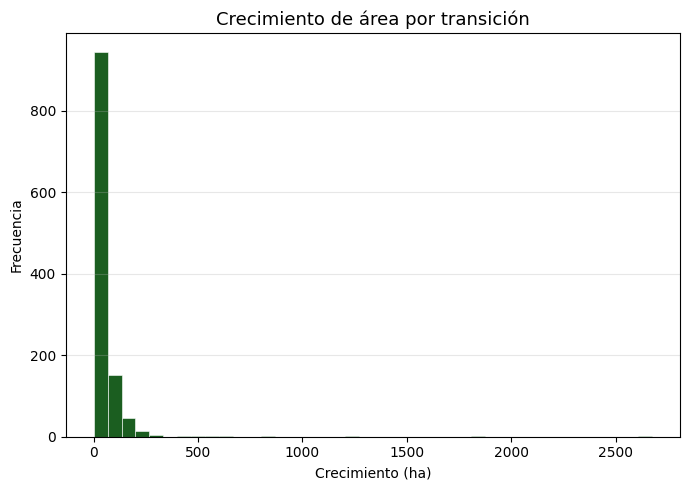

In [6]:
# --- Cómputo de transiciones t → t+1 ---
transition_rows = []

for (event, site), grp in clean.sort_values(["EVENT", "SITE", "HOUR"]).groupby(["EVENT", "SITE"]):
    grp = grp.sort_values("HOUR").reset_index(drop=True)
    for i in range(len(grp) - 1):
        r_t, r_t1 = grp.iloc[i], grp.iloc[i + 1]
        g_t, g_t1 = r_t.geometry, r_t1.geometry
        transition_rows.append({
            "EVENT": int(event), "SITE": int(site),
            "HOUR_t": int(r_t["HOUR"]), "HOUR_t1": int(r_t1["HOUR"]),
            "area_t_ha": g_t.area / 1e4, "area_t1_ha": g_t1.area / 1e4,
            "growth_ha": (g_t1.area - g_t.area) / 1e4,
            "iou": safe_iou(g_t, g_t1),
            "dice": safe_dice(g_t, g_t1),
            "t_inside_t1": bool(g_t1.covers(g_t)),
            "centroid_shift_m": float(g_t.centroid.distance(g_t1.centroid)),
        })

transition_df = pd.DataFrame(transition_rows)

# --- Resumen ---
print("=" * 55)
print("  MÉTRICAS DE TRANSICIÓN t → t+1")
print("=" * 55)
print(f"  Transiciones analizadas      : {len(transition_df):,}")
print(f"  t contenido en t+1           : {transition_df['t_inside_t1'].mean():.1%}")
print()
for label, col, fmt in [
    ("IoU", "iou", ".3f"),
    ("Dice", "dice", ".3f"),
    ("Crecimiento (ha)", "growth_ha", ".2f"),
    ("Desplazamiento centroide (m)", "centroid_shift_m", ".1f"),
]:
    s = transition_df[col].dropna()
    print(f"  {label}:")
    print(f"    Media / Mediana : {s.mean():{fmt}} / {s.median():{fmt}}")
    print(f"    P25 – P75       : {s.quantile(.25):{fmt}} – {s.quantile(.75):{fmt}}")
    print(f"    P95             : {s.quantile(.95):{fmt}}")
    print()

# ----------------------------------------------------------------
# Figura 1 – IoU entre perímetros consecutivos
# ----------------------------------------------------------------
fig_iou, ax_iou = plt.subplots(figsize=(7, 5))
ax_iou.hist(transition_df["iou"].dropna(), bins=40, color=GREEN_MAIN, edgecolor="white", linewidth=0.4)
ax_iou.set_title("IoU entre perímetros consecutivos", fontsize=13)
ax_iou.set_xlabel("IoU")
ax_iou.set_ylabel("Frecuencia")
ax_iou.grid(axis="y", alpha=0.3)
fig_iou.tight_layout()
plt.savefig("figuras_informe/fig_transicion_iou.png", dpi=150, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------
# Figura 2 – Área en t vs. área en t+1
# ----------------------------------------------------------------
fig_scatter, ax_scatter = plt.subplots(figsize=(7, 5))
ax_scatter.scatter(transition_df["area_t_ha"], transition_df["area_t1_ha"],
                   alpha=0.5, s=15, color=GREEN_MID)
lim = max(transition_df["area_t_ha"].max(), transition_df["area_t1_ha"].max())
ax_scatter.plot([0, lim], [0, lim], "--", color="gray", alpha=0.7)
ax_scatter.set_title("Área en t vs. área en t+1", fontsize=13)
ax_scatter.set_xlabel("Área en t (ha)")
ax_scatter.set_ylabel("Área en t+1 (ha)")
ax_scatter.grid(alpha=0.3)
fig_scatter.tight_layout()
plt.savefig("figuras_informe/fig_transicion_area_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------
# Figura 3 – Crecimiento de área por transición
# ----------------------------------------------------------------
fig_growth, ax_growth = plt.subplots(figsize=(7, 5))
ax_growth.hist(transition_df["growth_ha"].dropna(), bins=40, color=GREEN_DARK, edgecolor="white", linewidth=0.4)
ax_growth.set_title("Crecimiento de área por transición", fontsize=13)
ax_growth.set_xlabel("Crecimiento (ha)")
ax_growth.set_ylabel("Frecuencia")
ax_growth.grid(axis="y", alpha=0.3)
fig_growth.tight_layout()
plt.savefig("figuras_informe/fig_transicion_crecimiento.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Ejemplos de Evolución Temporal

Evolución del perímetro del fuego a lo largo de las horas simuladas para secuencias seleccionadas aleatoriamente (con $\geq 3$ pasos). El color indica la hora de la simulación.

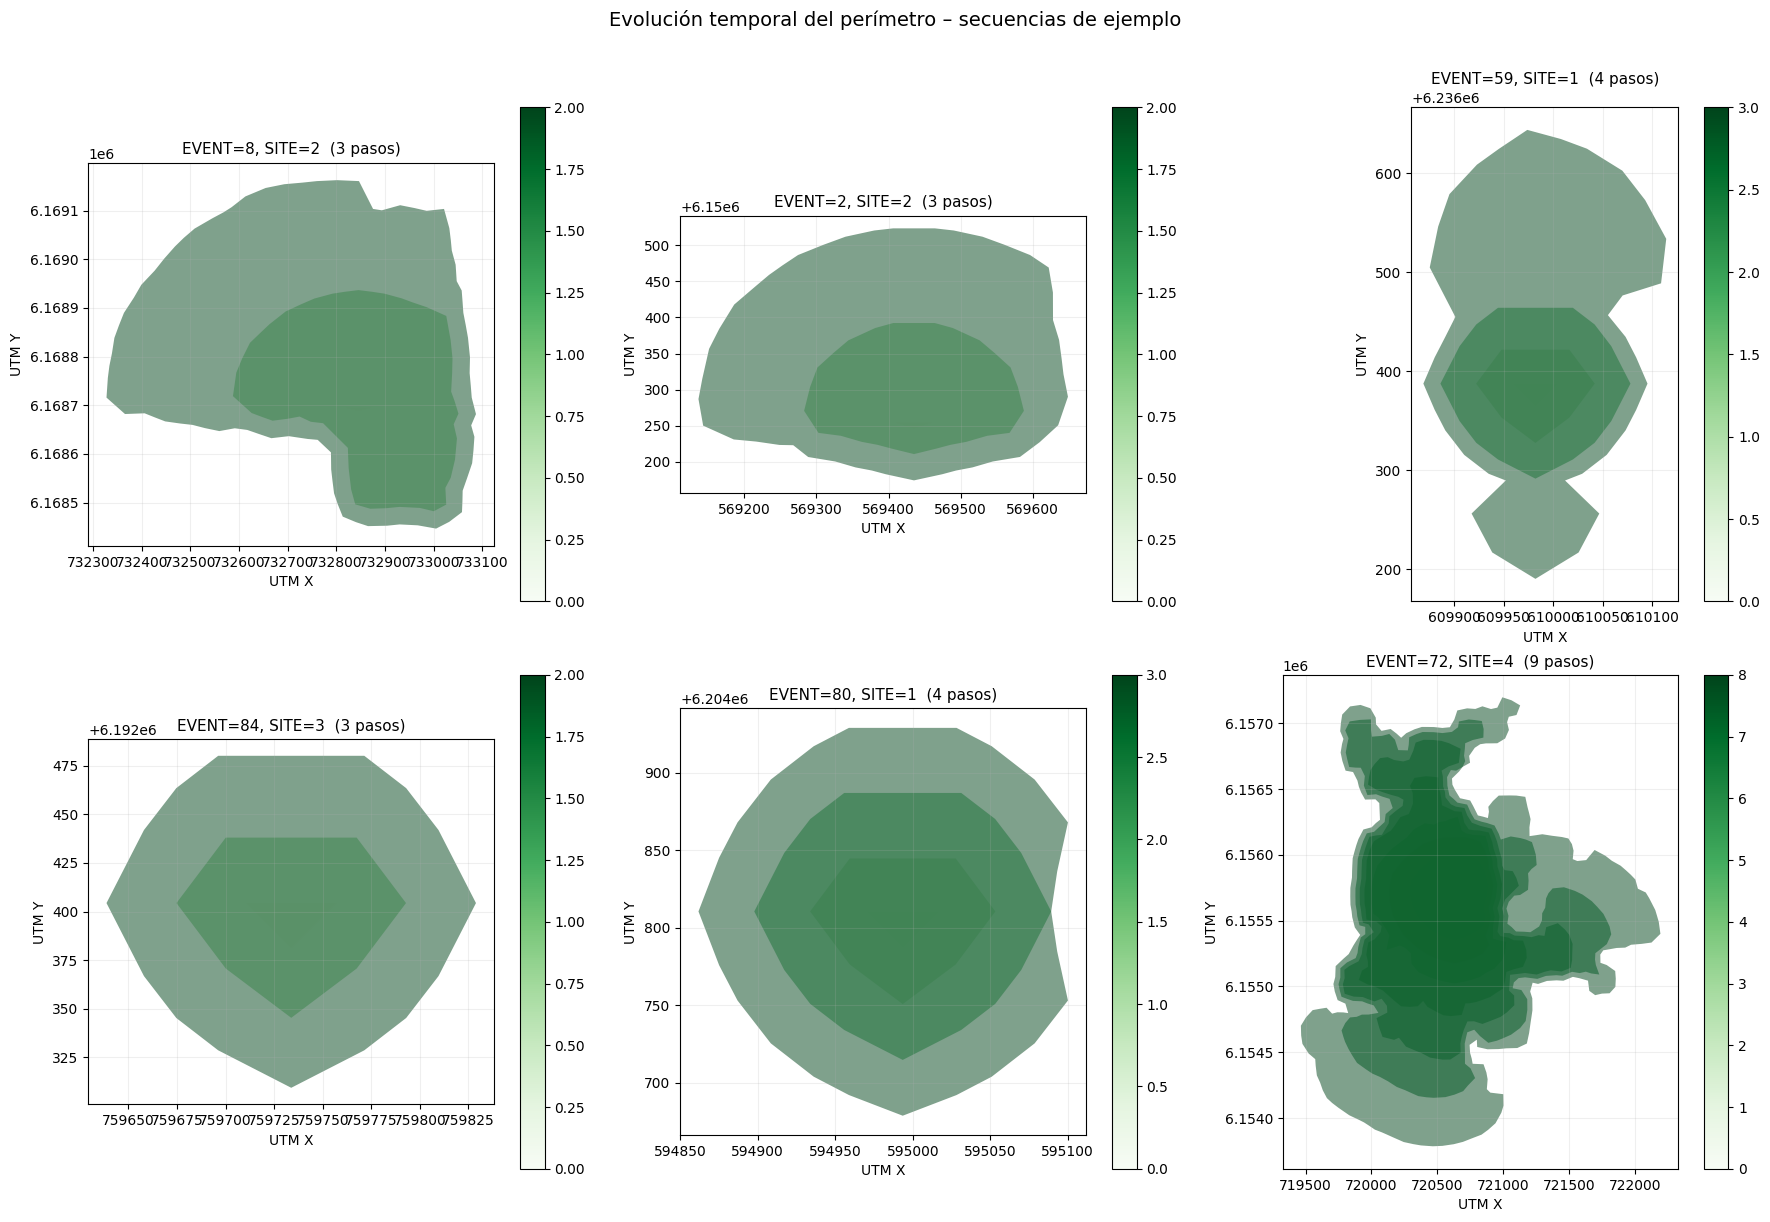

In [7]:
# --- Selección de secuencias con ≥ 3 pasos ---
eligible = clean_seq.loc[clean_seq["n_steps"] >= 3, ["EVENT", "SITE"]].copy()
eligible = eligible.sample(min(N_SAMPLE_SEQUENCES, len(eligible)), random_state=RANDOM_SEED)

n_examples = len(eligible)
ncols = 3
nrows = (n_examples + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
axes = axes.flatten()

for idx, (_, row) in enumerate(eligible.iterrows()):
    ev, si = row["EVENT"], row["SITE"]
    seq_gdf = clean[(clean["EVENT"] == ev) & (clean["SITE"] == si)].sort_values("HOUR")
    seq_gdf.plot(ax=axes[idx], column="HOUR", legend=True,
                 cmap=CMAP_GREEN, alpha=0.5)
    axes[idx].set_title(f"EVENT={ev}, SITE={si}  ({len(seq_gdf)} pasos)", fontsize=11)
    axes[idx].set_xlabel("UTM X")
    axes[idx].set_ylabel("UTM Y")
    axes[idx].grid(alpha=0.2)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Evolución temporal del perímetro – secuencias de ejemplo", fontsize=14, y=1.01)
fig.tight_layout()
plt.savefig("figuras_informe/fig_evolucion_temporal.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Hallazgos Clave

Resumen de las observaciones más relevantes para la formulación del problema de predicción.

In [8]:
print("=" * 60)
print("  HALLAZGOS CLAVE PARA EL MODELADO")
print("=" * 60)
print()
print("  1. DATOS DISPONIBLES")
print(f"     • {len(attrs):,} polígonos, {attrs['EVENT'].nunique()} eventos,")
print(f"       {attrs['event_site'].nunique()} secuencias EVENT×SITE")
print(f"     • {n_usable} secuencias utilizables para predicción t→t+1")
print(f"     • {n_transitions:,} transiciones consecutivas disponibles")
print()
print("  2. DINÁMICA DEL FUEGO")
print(f"     • El fuego crece de forma consistente: en el {transition_df['t_inside_t1'].mean():.1%}")
print(f"       de los casos el perímetro en t está contenido en t+1")
print(f"     • Crecimiento mediano por hora: {transition_df['growth_ha'].median():.1f} ha")
print(f"     • IoU mediano t/t+1: {transition_df['iou'].median():.3f}")
print(f"       (solapamiento moderado — expansión significativa por paso)")
print(f"     • Desplazamiento mediano del centroide: {transition_df['centroid_shift_m'].median():.0f} m")
print()
print("  3. RETOS IDENTIFICADOS")
print(f"     • Secuencias cortas: {seq_len_dist.get(2, 0)} de {len(clean_seq)}")
print(f"       secuencias tienen solo 2 pasos ({100*seq_len_dist.get(2,0)/len(clean_seq):.0f}%)")
print(f"     • Amplio rango de escalas: área de {clean['area_ha'].min():.4f} a")
print(f"       {clean['area_ha'].max():.0f} ha (distribución log-normal)")
print(f"     • IoU variable: std = {transition_df['iou'].std():.3f}, con una")
print(f"       concentración importante cerca de 0 en transiciones tempranas")

  HALLAZGOS CLAVE PARA EL MODELADO

  1. DATOS DISPONIBLES
     • 1,815 polígonos, 98 eventos,
       600 secuencias EVENT×SITE
     • 565 secuencias utilizables para predicción t→t+1
     • 1,171 transiciones consecutivas disponibles

  2. DINÁMICA DEL FUEGO
     • El fuego crece de forma consistente: en el 98.2%
       de los casos el perímetro en t está contenido en t+1
     • Crecimiento mediano por hora: 19.6 ha
     • IoU mediano t/t+1: 0.246
       (solapamiento moderado — expansión significativa por paso)
     • Desplazamiento mediano del centroide: 46 m

  3. RETOS IDENTIFICADOS
     • Secuencias cortas: 320 de 600
       secuencias tienen solo 2 pasos (53%)
     • Amplio rango de escalas: área de 0.0009 a
       5333 ha (distribución log-normal)
     • IoU variable: std = 0.287, con una
       concentración importante cerca de 0 en transiciones tempranas
